## Paper Replicating - Vision Transformer
 - https://arxiv.org/abs/2010.11929
 - using pytorch

In [1]:
## Get setup
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12 or int(torch.__version__.split(".")[0]) == 2, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.6.0
torchvision version: 0.21.0


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

/Users/sachinmurali/anaconda3/envs/transformers/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [4]:
## Get data
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                      destination="pizza_steak_sushi")

image_path

[INFO] data/pizza_steak_sushi directory exists, skipping download.


PosixPath('data/pizza_steak_sushi')

In [5]:
train_dir = image_path/"train"
test_dir = image_path/"test"

train_dir , test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [6]:
#set up data loader
from torchvision import transforms
IMAGE_SIZE = 224

manual_transform = transforms.Compose([
    transforms.Resize(size=(IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor()   
])

manual_transform

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)

In [7]:
BATCH_SIZE = 32

train_data_loader, test_data_loader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                  test_dir=test_dir,
                                                  transform=manual_transform,
                                                  batch_size=BATCH_SIZE
                                                  )


len(train_data_loader), len(test_data_loader), class_names

(8, 3, ['pizza', 'steak', 'sushi'])

In [8]:
## Visualize a dingle image
# get the first batch of 32
image_batch, label_batch = next(iter(train_data_loader))

In [9]:
# get a a singel image and label

image, label = image_batch[0] , label_batch[0]

image.shape , label.shape

(torch.Size([3, 224, 224]), torch.Size([]))

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

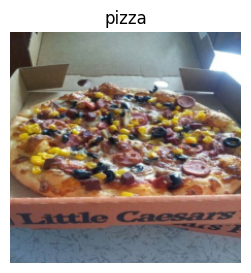

In [10]:
# plot the image with matplot lib
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))

plt.imshow(image.permute(1,2,0))

plt.title(class_names[label.item()])

plt.axis("off")


In [11]:
image

tensor([[[0.1804, 0.1686, 0.1647,  ..., 0.3255, 0.3255, 0.3098],
         [0.1765, 0.1725, 0.1647,  ..., 0.3294, 0.3294, 0.3137],
         [0.1765, 0.1804, 0.1725,  ..., 0.3373, 0.3333, 0.3137],
         ...,
         [0.2941, 0.3529, 0.3569,  ..., 0.3804, 0.3569, 0.3804],
         [0.3255, 0.3490, 0.3686,  ..., 0.4118, 0.3922, 0.3647],
         [0.3529, 0.3412, 0.3490,  ..., 0.4275, 0.4392, 0.3961]],

        [[0.1255, 0.1176, 0.1137,  ..., 0.3686, 0.3765, 0.3608],
         [0.1255, 0.1216, 0.1137,  ..., 0.3804, 0.3804, 0.3647],
         [0.1255, 0.1294, 0.1216,  ..., 0.3882, 0.3882, 0.3725],
         ...,
         [0.3804, 0.4392, 0.4431,  ..., 0.4549, 0.4314, 0.4549],
         [0.4078, 0.4314, 0.4510,  ..., 0.4863, 0.4706, 0.4431],
         [0.4353, 0.4235, 0.4314,  ..., 0.5059, 0.5176, 0.4745]],

        [[0.1137, 0.0980, 0.0902,  ..., 0.4471, 0.4431, 0.4275],
         [0.1020, 0.0980, 0.0902,  ..., 0.4588, 0.4588, 0.4431],
         [0.1020, 0.1059, 0.0980,  ..., 0.4824, 0.4824, 0.

In [12]:
height = 224 #H
width = 224  #W
color_channel = 3 #C
patch_size = 16 # P

# calculate the number off patchs
# N = HW / P²
num_of_patchs = int((height * width) / patch_size**2)

num_of_patchs # N

196

In [13]:
# Input shape H*W*C
embedding_layer_input_shape = (height , width , color_channel)
# Output shape
embedding_layer_output_shape =  (num_of_patchs , (patch_size**2 * color_channel))

print(f"Inputs shape : {embedding_layer_input_shape}")
print(f"Output shape : {embedding_layer_output_shape}")

Inputs shape : (224, 224, 3)
Output shape : (196, 768)


In [14]:
image

tensor([[[0.1804, 0.1686, 0.1647,  ..., 0.3255, 0.3255, 0.3098],
         [0.1765, 0.1725, 0.1647,  ..., 0.3294, 0.3294, 0.3137],
         [0.1765, 0.1804, 0.1725,  ..., 0.3373, 0.3333, 0.3137],
         ...,
         [0.2941, 0.3529, 0.3569,  ..., 0.3804, 0.3569, 0.3804],
         [0.3255, 0.3490, 0.3686,  ..., 0.4118, 0.3922, 0.3647],
         [0.3529, 0.3412, 0.3490,  ..., 0.4275, 0.4392, 0.3961]],

        [[0.1255, 0.1176, 0.1137,  ..., 0.3686, 0.3765, 0.3608],
         [0.1255, 0.1216, 0.1137,  ..., 0.3804, 0.3804, 0.3647],
         [0.1255, 0.1294, 0.1216,  ..., 0.3882, 0.3882, 0.3725],
         ...,
         [0.3804, 0.4392, 0.4431,  ..., 0.4549, 0.4314, 0.4549],
         [0.4078, 0.4314, 0.4510,  ..., 0.4863, 0.4706, 0.4431],
         [0.4353, 0.4235, 0.4314,  ..., 0.5059, 0.5176, 0.4745]],

        [[0.1137, 0.0980, 0.0902,  ..., 0.4471, 0.4431, 0.4275],
         [0.1020, 0.0980, 0.0902,  ..., 0.4588, 0.4588, 0.4431],
         [0.1020, 0.1059, 0.0980,  ..., 0.4824, 0.4824, 0.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

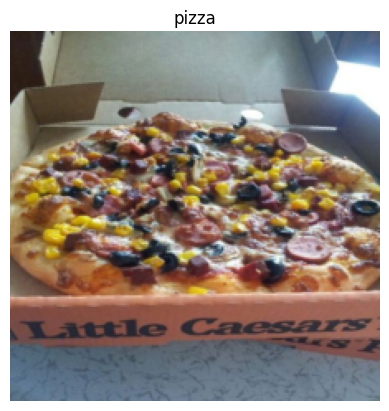

In [15]:
import matplotlib.pyplot as plt

plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis('off')

In [16]:
image.shape

torch.Size([3, 224, 224])

In [17]:
image_permuted = image.permute(1,2,0)

image_permuted.shape

torch.Size([224, 224, 3])

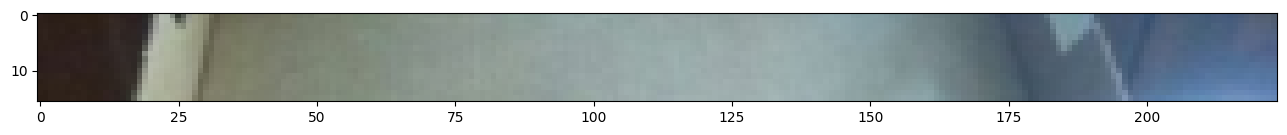

In [18]:
plt.figure(figsize=(16,16))
plt.imshow(image_permuted[:16, :, :])

In [19]:
img_size = 224
patch_size = 16

num_of_patchs = img_size / patch_size

num_of_patchs

14.0

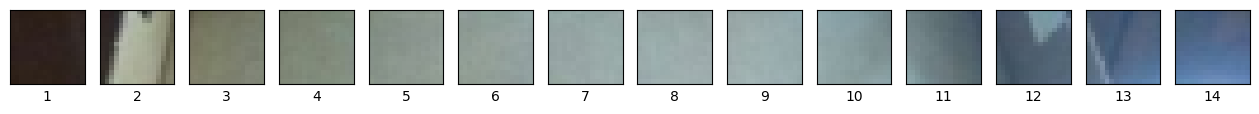

In [20]:
fig, axis = plt.subplots(nrows=1,
                         ncols=img_size // patch_size,
                         figsize = (patch_size, patch_size),
                         sharex=True,
                         sharey=True)



for i, patch in enumerate(range(0,img_size, patch_size)):
    axis[i].imshow(image_permuted[:16, patch:patch+patch_size, :])
    axis[i].set_xlabel(i+1)
    axis[i].set_xticks([])
    axis[i].set_yticks([])

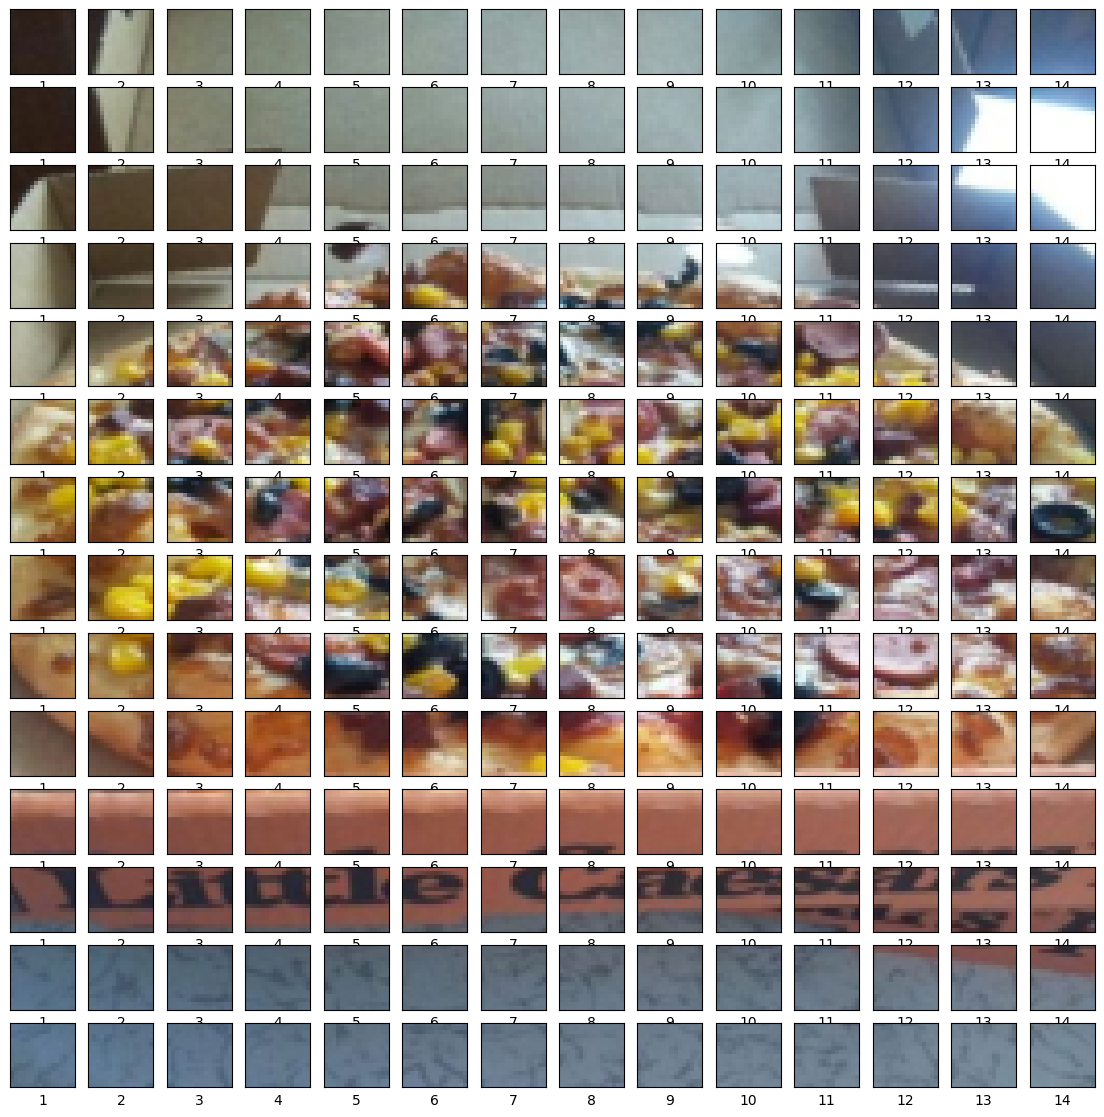

In [21]:
fig, axis = plt.subplots(nrows=img_size // patch_size,
                         ncols=img_size // patch_size,
                         figsize = (num_of_patchs, num_of_patchs),
                         sharex=True,
                         sharey=True)



for i, patch_height in enumerate(range(0,img_size, patch_size)):
    for j, patch_width in enumerate(range(0,img_size, patch_size)):

        axis[i,j].imshow(image_permuted[patch_height:patch_height+patch_size,
                                        patch_width:patch_width+patch_size, :])
        axis[i,j].set_xlabel(j+1)
        axis[i,j].set_xticks([])
        axis[i,j].set_yticks([])

In [22]:
# Create patch's using CNN
from torch import nn

patch_size = 16

conv2d = nn.Conv2d(in_channels=3, # color channel
                   out_channels=768 ,# D
                   kernel_size=patch_size,
                   stride=patch_size,
                   padding=0)

conv2d


Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

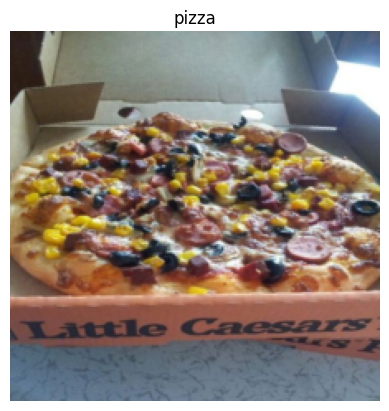

In [23]:
# view a ingle imaage
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis('off')

In [24]:
image.shape, image.unsqueeze(0).shape

(torch.Size([3, 224, 224]), torch.Size([1, 3, 224, 224]))

In [25]:
image_out_conv = conv2d(image.unsqueeze(0))

image_out_conv.shape

torch.Size([1, 768, 14, 14])

In [26]:
flat = nn.Flatten(start_dim=2)

flattened_image = flat(image_out_conv)

In [27]:
flattened_image.shape

torch.Size([1, 768, 196])

In [28]:
# make erything a class

class PathEmbedd(nn.Module):
    def __init__(self, in_channel:int = 3 , patch_size:int = 16, embed_dim : int = 768): # 768 for ViT BAse
        super().__init__()
        # create a layer, tuen image into embedded path
        self.patcher = nn.Conv2d(in_channels=in_channel, out_channels=embed_dim, kernel_size=patch_size, stride=patch_size, padding=0)
        # now lets flatten, our patch embed into sequence
        self.flatten = nn.Flatten(start_dim=2, end_dim=3)
        self.patch_size = patch_size
        
    def forward(self, x):
        # create an assertion about the input image shape
        image_resolution = x.shape[-1]
        assert image_resolution % self.patch_size == 0 , "Input image must be divisibe by patch size"
        
        #perform forward pass
        x_patcher = self.patcher(x)
        x_flatten = self.flatten(x_patcher)
        
        return x_flatten.permute(0,2,1)
        
        
        
        
        


In [30]:
torch.manual_seed(42)

pachify =  PathEmbedd(in_channel=3, patch_size=16, embed_dim=768)

# let pass an image with batch dimension
batch_image = image.unsqueeze(0)

batch_image.shape

patch_embedded_image = pachify(batch_image)

In [31]:
patch_embedded_image.shape

torch.Size([1, 196, 768])

In [32]:
batch_size = patch_embedded_image.shape[0]
embedded_dim = patch_embedded_image.shape[-1]

batch_size,  embedded_dim

(1, 768)

In [35]:
# create a class token embedding (D)
class_token = nn.Parameter(torch.ones(size=(batch_size,1,embedded_dim), requires_grad=True))

class_token.shape

torch.Size([1, 1, 768])

In [37]:
# append the class token to path embed

path_embed_to_class_embed = torch.cat((class_token, patch_embedded_image), dim=1)

path_embed_to_class_embed.shape

torch.Size([1, 197, 768])

In [38]:
path_embed_to_class_embed

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.1826,  0.0203, -0.0561,  ...,  0.1010, -0.0760,  0.0667],
         [-0.7196,  0.1615, -0.2192,  ...,  0.5178, -0.1064,  0.0814],
         ...,
         [-0.5140,  0.1800, -0.1956,  ...,  0.4086, -0.2054,  0.1498],
         [-0.5620,  0.1415, -0.1795,  ...,  0.4230, -0.2051,  0.1731],
         [-0.5243,  0.2046, -0.1920,  ...,  0.4245, -0.2061,  0.2046]]],
       grad_fn=<CatBackward0>)

In [ ]:
bad_image = torch.rand(size=(1,224,224))

path_embed_to_class_embed

In [60]:
# putting it al together
torch.manual_seed(42)

patch_size = 16

# Image tensor shape
print(f"Iage shape : {image.shape}")

height, width = image.shape[1] , image.shape[2]


# add batch dim to image
x = image.unsqueeze(0)
x.shape

# create a patch embedding layer
patch_embedded_layer = PathEmbedd(in_channel=3, patch_size=patch_size, embed_dim=768)

# pass the input x tghrough the path embed layer

patch_embedding = patch_embedded_layer(x)

patch_embedding.shape

# create clas embedding toke
batch_size = patch_embedding.shape[0]
embedding_dim = patch_embedding.shape[-1]

class_token = nn.Parameter(torch.ones(size=(batch_size, 1 , embedded_dim)), requires_grad=True)
class_token.shape

# prepend the class token to pathc embedding
patch_embed_class_token = torch.cat((class_token, patch_embedding), dim=1)

patch_embed_class_token.shape

# create position embedding and add it to the tok
num_of_patch = int((height*width) / patch_size ** 2) 
position_embed = nn.Parameter(torch.ones(size=(batch_size, num_of_patch + 1 , embedded_dim)))

position_embed.shape

patch_postion_embed = patch_embed_class_token + position_embed

patch_postion_embed.shape

Iage shape : torch.Size([3, 224, 224])


torch.Size([1, 197, 768])

In [61]:
patch_postion_embed

tensor([[[2.0000, 2.0000, 2.0000,  ..., 2.0000, 2.0000, 2.0000],
         [0.8174, 1.0203, 0.9439,  ..., 1.1010, 0.9240, 1.0667],
         [0.2804, 1.1615, 0.7808,  ..., 1.5178, 0.8936, 1.0814],
         ...,
         [0.4860, 1.1800, 0.8044,  ..., 1.4086, 0.7946, 1.1498],
         [0.4380, 1.1415, 0.8205,  ..., 1.4230, 0.7949, 1.1731],
         [0.4757, 1.2046, 0.8080,  ..., 1.4245, 0.7939, 1.2046]]],
       grad_fn=<AddBackward0>)

In [72]:
a = nn.Parameter(torch.ones(size=(2,3)))
b= torch.ones(size=(2,3))
a, b

(Parameter containing:
 tensor([[1., 1., 1.],
         [1., 1., 1.]], requires_grad=True),
 tensor([[1., 1., 1.],
         [1., 1., 1.]]))